# Project 4: Gaussian Processes and Kernel Methods
Sophia Klymchuk and Devin Zhang

Instructions:

Re-do the second part of your linear regression assignment (i.e. the replication of figure 3.8) with Gaussian processes. This basically involves replacing your prediction equations (3.58 and 3.59) with the GP predictions (6.66 and 6.67). Use the Gaussian kernel (eqn 6.23) to build the covariance matrix C (eqn 6.62)

Equation 3.58: Predictive Distribution <br>
$P(t|x,\mathbf{t},\alpha,\beta) = N\left(t|\mathbf{m}_N^T \phi(x), \sigma_N^2(x)\right)$

Equation 3.59: Variance of Predictive Distribution <br>
$\sigma_N^2(x) = \frac{1}{\beta} + \phi(x)^T \mathbf{S}_N \phi(x)$

<br>

Conditional Distribution:
$P(t_{N+1} | \mathbf{t})$

Equation 6.66: Mean of conditional distribution <br>
$m(x_{N+1}) = \mathbf{k}^T \mathbf{C}_N^{-1} \mathbf{t}$

Equation 6.67: Covariance of conditional distribution <br>
$\sigma^2 (x_{N+1}) = c - \mathbf{k}^T \mathbf{C}_N^{-1} \mathbf{k}; \quad c=k(x_{N+1}, x_{N+1}) + \beta^{-1}$

<br>

Equation 6.23: Gaussian kernel <br>
$k(x,x') = e^{(- ||x-x'||^2 / 2\sigma^2)}$

Equation 6.62: Covariance matrix $\mathbf{C}$ <br>
$C(x_n, x_m) = k(x_n, x_m) + \beta^{-1} \delta_{nm}$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import multivariate_normal

## Sinusoidal True Relationship
Model: 9 Gaussian basis functions

### Initiate true relationship and noise

In [3]:
lower_x_bound, upper_x_bound = 0, 1
true_freq = 2 * np.pi
true_noise_std = 0.1  # This is the noise that gets added when we draw a target observation. chose kinda randomly.
true_noise_var = true_noise_std**2
true_noise_beta = 1 / true_noise_var

###Basis function helper

In [4]:
# Basis functions: 9 Gaussian basis functions
# The mu_j are spatial locations of the basis functions
# We will later space them evenly (as in the example in the book)
def phi(x, mu_j, s=0.1):  # s parameter unimportant since these will get scaled by weights later
    return np.exp(-0.5 * ((x - mu_j)/s)**2)

### Initiate prior

In [5]:
mu_0 = np.zeros(9)  # initial guesses for [w0, w1, ..., w8]
alpha_0 = 2.0       # single prior precision for both weights
s_0 = (1/alpha_0) * np.eye(9)  # prior covariance matrix. assume uncorrelated, single variance

### Start observations loop

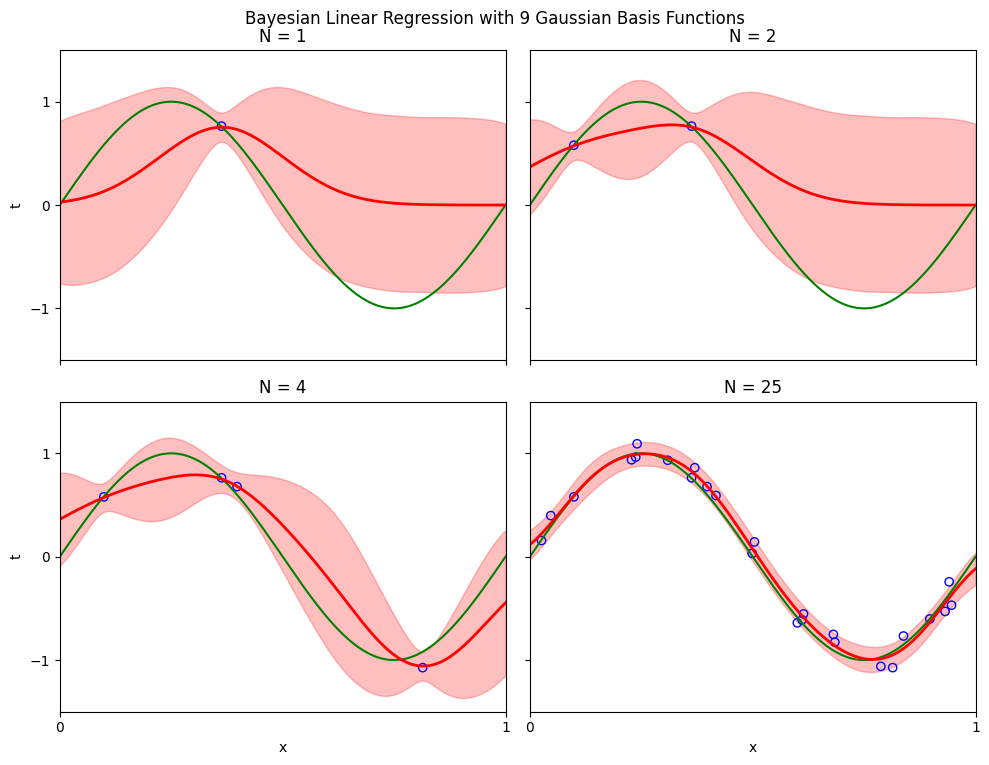

In [6]:
"""
INITIALIZATIONS BEFORE LOOP
"""
num_observations = 1000
x_obs_history, t_obs_history = [], []  # store x and target var t
phi_x = []  # Design matrix rows for 9 Gaussian basis functions; each row = [phi_1(x), ..., phi_9(x)]

# Fixed basis locations and x-grid for plotting
mu_js = np.linspace(lower_x_bound, upper_x_bound, 9)
x_plot = np.linspace(lower_x_bound, upper_x_bound, 400)

# Current posterior parameters (start at prior)
mu_n, s_n = mu_0.copy(), s_0.copy()

# Figure and which N observations to snapshot
snapshot_Ns = [1, 2, 4, 25]
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

"""
START OUR OBSERVATIONS LOOP. OBSERVE, PLOT, CALCULATE, ETC
"""
for n in range(num_observations):

    # Sample an x observation
    x_obs = np.random.uniform(lower_x_bound, upper_x_bound)

    # Generate noisy target t = sin(frequency * x) + ε
    true_y = np.sin(true_freq * x_obs)
    t_obs = true_y + np.random.normal(0.0, true_noise_std)

    # Append to histories
    x_obs_history.append(x_obs)
    t_obs_history.append(t_obs)

    # Design matrix row for this x
    phi_x.append([phi(x_obs, mu_j) for mu_j in mu_js])

    # Convert our lists to arrays for linalg calcs
    Phi = np.asarray(phi_x)  # nx9
    t_vec = np.asarray(t_obs_history)  # n,

    # Update our prior parameters to get our posterior
    s_n_inv = np.linalg.inv(s_0) + true_noise_beta * (Phi.T @ Phi)  # 9x9
    s_n = np.linalg.inv(s_n_inv)  # 9x9
    mu_n = true_noise_beta * (s_n @ Phi.T @ t_vec)  # 9,

    # Now predictive distribution for plotting on the same grid as the plot
    sigma_n = []
    mean_pred = []
    for xi in x_plot:
        phi_x_n = np.array([phi(xi, mu_j) for mu_j in mu_js])  # 9,
        sigma_n.append(np.sqrt(1/true_noise_beta + phi_x_n.T @ s_n @ phi_x_n))
        mean_pred.append(mu_n.T @ phi_x_n)
    mean_pred = np.asarray(mean_pred).ravel()
    sigma_n = np.asarray(sigma_n).ravel()

    # Get snapshot of progress and plot at N observations
    N_now = len(t_obs_history)
    if N_now in snapshot_Ns:
        ax = axes[snapshot_Ns.index(N_now)]
        # true function
        ax.plot(x_plot, np.sin(true_freq * x_plot), color='green', linewidth=1.5)
        # predictive mean
        ax.plot(x_plot, mean_pred, color='red', linewidth=2)
        # +- 1 SD band
        ax.fill_between(x_plot, mean_pred - sigma_n, mean_pred + sigma_n,
                        color='red', alpha=0.25)
        # observations used so far
        ax.scatter(x_obs_history[:N_now], t_obs_history[:N_now],
                   facecolors='none', edgecolors='blue')

        ax.set_title(f"N = {N_now}")
        ax.set_xlim(lower_x_bound, upper_x_bound)
        ax.set_ylim(-1.5, 1.5)
        ax.set_xticks([0, 1])
        ax.set_yticks([-1, 0, 1])

# labels layout
for ax in axes[2:]:
    ax.set_xlabel("x")
for ax in axes[::2]:
    ax.set_ylabel("t")

fig.suptitle("Bayesian Linear Regression with 9 Gaussian Basis Functions", y=0.95, fontsize=12)
fig.tight_layout()
fig.subplots_adjust(top=0.90)
plt.show()



## Gaussian Process redo of Figure 3.8

We replace the Bayesian linear regression predictive equations (3.58–3.59) with GP predictive equations (6.66–6.67).
We use the Gaussian kernel (6.23) to build the covariance matrix $\mathbf{C}$ per (6.62).


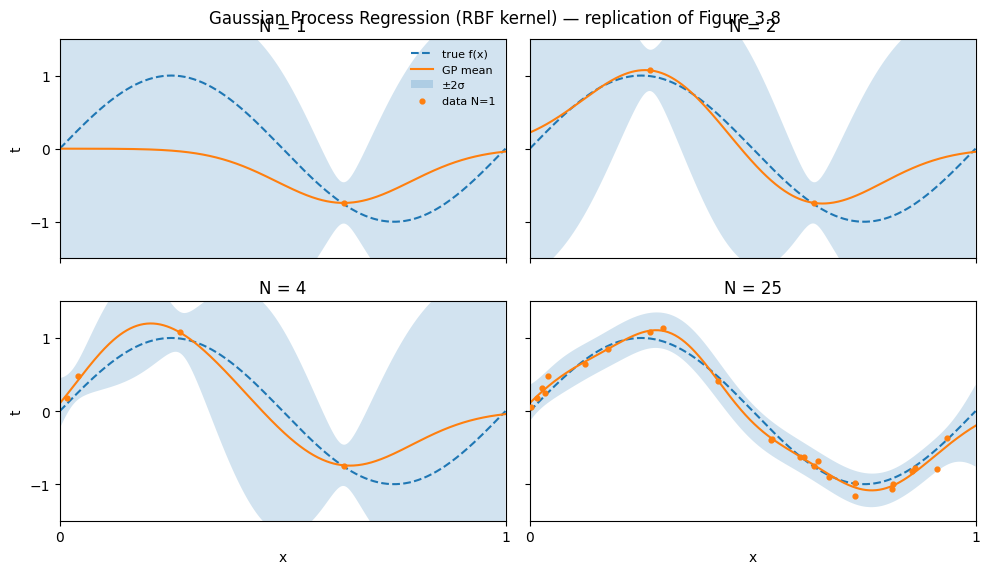

In [7]:

import numpy as np
import matplotlib.pyplot as plt

# Use existing noise settings and bounds if present
try:
    lower, upper = lower_x_bound, upper_x_bound
except NameError:
    lower, upper = 0.0, 1.0

try:
    noise_std = true_noise_std
    noise_var = true_noise_var
    beta = true_noise_beta
except NameError:
    noise_std = 0.1
    noise_var = noise_std ** 2
    beta = 1.0 / noise_var

# RBF kernel k(x,x') = exp(-||x-x'||^2 / (2 l^2))
def rbf_kernel(X1, X2, lengthscale=0.1, sigma_f=1.0):
    X1 = np.atleast_2d(X1).reshape(-1, 1)
    X2 = np.atleast_2d(X2).reshape(-1, 1)
    dists = (X1 - X2.T) ** 2
    return (sigma_f ** 2) * np.exp(-0.5 * dists / (lengthscale ** 2))

# GP predictive mean and variance per 6.66 and 6.67
def gp_posterior(X_train, y_train, X_test, lengthscale=0.1, sigma_f=1.0, noise_var=noise_var):
    K = rbf_kernel(X_train, X_train, lengthscale, sigma_f) + noise_var * np.eye(len(X_train))  # C_N
    K_s = rbf_kernel(X_test, X_train, lengthscale, sigma_f)
    K_ss = rbf_kernel(X_test, X_test, lengthscale, sigma_f)
    jitter = 1e-10
    K_inv = np.linalg.inv(K + jitter * np.eye(K.shape[0]))
    mean = K_s @ (K_inv @ y_train)
    cov = K_ss - K_s @ K_inv @ K_s.T
    var = np.clip(np.diag(cov), a_min=0.0, a_max=None)
    return mean.ravel(), var

# True function for Figure 3.8 style
def f_true(x):
    return np.sin(2*np.pi*x)

# Generate sequential observations
rng = np.random.default_rng(0)
x_plot = np.linspace(lower, upper, 400)
snapshot_Ns = [1, 2, 4, 25]

# Pre-generate a stream of observations to keep consistent across snapshots
N_stream = 1000
x_stream = rng.uniform(lower, upper, size=N_stream)
t_stream = f_true(x_stream) + rng.normal(0, noise_std, size=N_stream)

# Reasonable hyperparameters for the unit interval sine
ell = 0.15
sf = 1.0

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True, sharey=True)
axes = axes.ravel()

for ax, N in zip(axes, snapshot_Ns):
    Xn = x_stream[:N]
    yn = t_stream[:N]
    mean, var = gp_posterior(Xn, yn, x_plot, lengthscale=ell, sigma_f=sf, noise_var=noise_var)
    std = np.sqrt(var + noise_var)  # include noise for predictive t (as in 6.67: c includes beta^{-1})

    ax.plot(x_plot, f_true(x_plot), linestyle="--", label="true f(x)")
    ax.plot(x_plot, mean, label="GP mean")
    ax.fill_between(x_plot, mean - 2*std, mean + 2*std, alpha=0.2, label="±2σ")
    ax.scatter(Xn, yn, s=12, zorder=3, label=f"data N={N}")
    ax.set_title(f"N = {N}")
    ax.set_xlim(lower, upper)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks([lower, upper])
    ax.set_yticks([-1, 0, 1])

# Labels and legend
for ax in axes[2:]:
    ax.set_xlabel("x")
for ax in axes[::2]:
    ax.set_ylabel("t")
axes[0].legend(loc="upper right", fontsize=8, ncol=1, frameon=False)

fig.suptitle("Gaussian Process Regression (RBF kernel) — replication of Figure 3.8", y=0.95, fontsize=12)
fig.tight_layout()
fig.subplots_adjust(top=0.90)
plt.show()


## Stretch Goal
Stretch goal, 5 points. Read the Practical Guide to Support Vector Classification paper, implement the grid search procedure on the same datasets you used for project 3

--- Generating Synthetic Data (Two-Class Multivariate Normal) ---
--- Processing Synthetic Dataset ---
Starting Grid Search...
Fitting 5 folds for each of 110 candidates, totalling 550 fits
Best parameters found: {'C': np.float64(32.0), 'gamma': np.float64(0.0078125)}
Best Cross-Validation Score: 0.9214
Final Test Set Accuracy: 0.9333



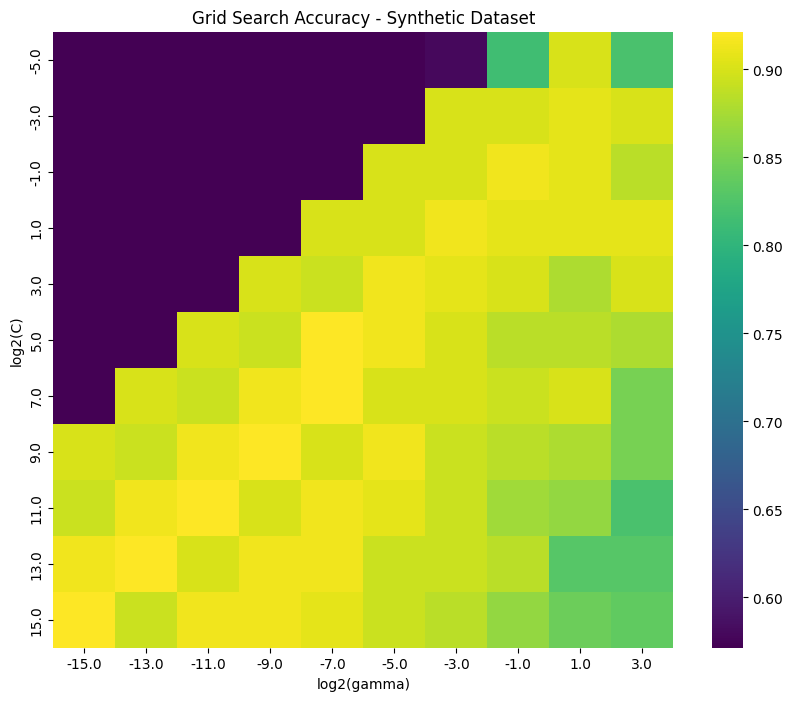

--- Loading Diabetes Dataset (Binary Classification Task) ---
--- Processing Diabetes Dataset ---
Starting Grid Search...
Fitting 5 folds for each of 110 candidates, totalling 550 fits
Best parameters found: {'C': np.float64(8192.0), 'gamma': np.float64(0.001953125)}
Best Cross-Validation Score: 0.7376
Final Test Set Accuracy: 0.7594



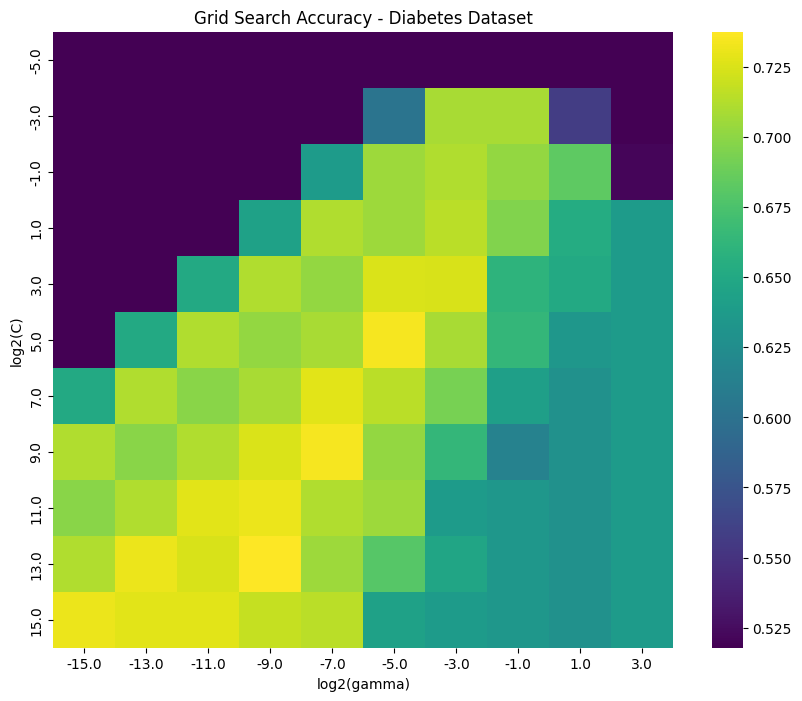

0.7593984962406015

In [ ]:
# Extra imports just for this section
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import load_diabetes
from sklearn.metrics import accuracy_score


# 1. Define the "Cookbook" Procedure from the SVM Guide

def run_svm_grid_search(X_train, y_train, X_test, y_test, dataset_name="Dataset"):
    """
    1. Transform data to SVM package format (handled by sklearn)
    2. Conduct simple scaling on the data (Section 2.2)
    3. Consider the RBF kernel (Section 3.1)
    4. Use cross-validation to find the best parameter C and gamma (Section 3.2)
    5. Use the best parameter C and gamma to train the whole training set
    6. Test
    """
    print(f"--- Processing {dataset_name} ---")

    # The guide emphasizes scaling to avoid attributes in greater numeric ranges dominating those in smaller ranges. Scale each attribute to [-1, +1] or [0, 1]
    # Use the SAME scaling factors for both training and testing matrices
    # We fit the scaler ONLY on the training data to avoid data leakage.
    scaling_range = (-1, 1)
    scaler = MinMaxScaler(feature_range=scaling_range)

    # Fit scaler on training data and transform training data
    X_train_scaled = scaler.fit_transform(X_train)
    # Transform test data using the parameters found from training data
    X_test_scaled = scaler.transform(X_test)

    # The guide recommends a "grid-search" on C and gamma using cross-validation
    # It specifically suggests trying exponentially growing sequences

    # C ranges from 2^-5 to 2^15 with step 2 (i.e., 2^-5, 2^-3, ... 2^15)
    C_range = 2.0 ** np.arange(-5, 16, 2)

    # Gamma ranges from 2^-15 to 2^3 with step 2 (i.e., 2^-15, 2^-13, ... 2^3)
    gamma_range = 2.0 ** np.arange(-15, 4, 2)

    # Create a dictionary for GridSearchCV
    param_grid = dict(gamma=gamma_range, C=C_range)

    # The guide states "In general, the RBF kernel is a reasonable first choice"
    # We use 5-fold cross-validation as suggested in the guide's examples
    grid = GridSearchCV(
        SVC(kernel='rbf'),   # Use RBF Kernel
        param_grid=param_grid,
        cv=5,                # 5-fold Cross-Validation
        n_jobs=-1,           # Use all CPU cores (Guide notes grid search is easily parallelizable )
        verbose=1
    )

    # Execute the grid search
    # This trains an SVM for every combination of C and gamma on 5 different folds
    print("Starting Grid Search...")
    grid.fit(X_train_scaled, y_train)

    print(f"Best parameters found: {grid.best_params_}")
    print(f"Best Cross-Validation Score: {grid.best_score_:.4f}")

    # GridSearchCV automatically refits the model with the best C and gamma on the entire training set, satisfying the guide's requirement:
    # "Use the best parameter C and gamma to train the whole training set"
    best_model = grid.best_estimator_

    # Predict on the (scaled) test set
    y_pred = best_model.predict(X_test_scaled)
    test_accuracy = accuracy_score(y_test, y_pred)

    print(f"Final Test Set Accuracy: {test_accuracy:.4f}\n")

    # VISUALIZATION
    # Replicates Figure 2/3 style heatmaps from the guide
    # This helps visualize the "better region" for parameters.
    scores = grid.cv_results_['mean_test_score'].reshape(len(C_range), len(gamma_range))

    plt.figure(figsize=(10, 8))
    sns.heatmap(scores, annot=False, cmap='viridis',
                xticklabels=np.round(np.log2(gamma_range), 1),
                yticklabels=np.round(np.log2(C_range), 1))
    plt.xlabel('log2(gamma)')
    plt.ylabel('log2(C)')
    plt.title(f'Grid Search Accuracy - {dataset_name}')
    plt.show()

    return test_accuracy

# 2. Dataset 1: Synthetic (Recreated from Project 3)

print("--- Generating Synthetic Data (Two-Class Multivariate Normal) ---")
# Parameters taken from ECE_474_P3_Lin_Class.ipynb
n_samples = 200
mu1 = np.array([1, 1])
mu2 = np.array([-1, -1])
sigma = np.eye(2)

# Generate data
X1 = np.random.multivariate_normal(mu1, sigma, int(n_samples/2))
X2 = np.random.multivariate_normal(mu2, sigma, int(n_samples/2))

# Combine and create labels
X_syn = np.vstack([X1, X2])
y_syn = np.hstack([np.ones(int(n_samples/2)), np.zeros(int(n_samples/2))])

# Split into train/test (Guide requires separating data into training and testing sets)
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42
)

# Execute the SVM Procedure
run_svm_grid_search(X_train_syn, y_train_syn, X_test_syn, y_test_syn, "Synthetic Dataset")

# 3. Dataset 2: Diabetes (Same as Project 3 )

print("--- Loading Diabetes Dataset (Binary Classification Task) ---")
data = load_diabetes()
X_diab = data.data

# Create binary classes: High progression (1) vs Low progression (0) based on median
y_diab = (data.target > np.median(data.target)).astype(int)

# Split into train/test
X_train_diab, X_test_diab, y_train_diab, y_test_diab = train_test_split(
    X_diab, y_diab, test_size=0.3, random_state=42
)

# Execute the SVM Procedure
run_svm_grid_search(X_train_diab, y_train_diab, X_test_diab, y_test_diab, "Diabetes Dataset")